In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Spark_MLlib_AnswerKey") \
    .getOrCreate()

# Đường dẫn gốc trên HDFS (Thay đổi theo thực tế của hệ thống cài đặt)
HDFS_PATH = "hdfs://localhost:9000/data/"

# 3.1. Bài 1: Hồi quy tuyến tính (Linear Regression)

In [54]:
df_wine = spark.read.csv(HDFS_PATH + "winequality-red.csv", header=True, inferSchema=True, sep=";")
df_wine.show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|           

In [55]:
# 2. Tiền xử lý (Gộp vector và Chuẩn hóa)
from pyspark.ml.feature import VectorAssembler, StandardScaler

feature_columns = [c for c in df_wine.columns if c != 'quality']
assembler = VectorAssembler(inputCols=feature_columns, outputCol="raw_features")
df_wine = assembler.transform(df_wine)

In [56]:
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_wine)
df_wine_scaled = scaler_model.transform(df_wine)

In [57]:
from pyspark.ml.regression import LinearRegression

train_data_wine, test_data_wine = df_wine_scaled.randomSplit([0.8, 0.2], seed=42)
lr = LinearRegression(featuresCol='features', labelCol='quality')
lr_model = lr.fit(train_data_wine)

In [58]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions_wine = lr_model.transform(test_data_wine)
evaluator_wine = RegressionEvaluator(labelCol="quality", predictionCol="prediction", metricName="rmse")
print(f"RMSE (Linear Regression): {evaluator_wine.evaluate(predictions_wine):.4f}")

RMSE (Linear Regression): 0.6747


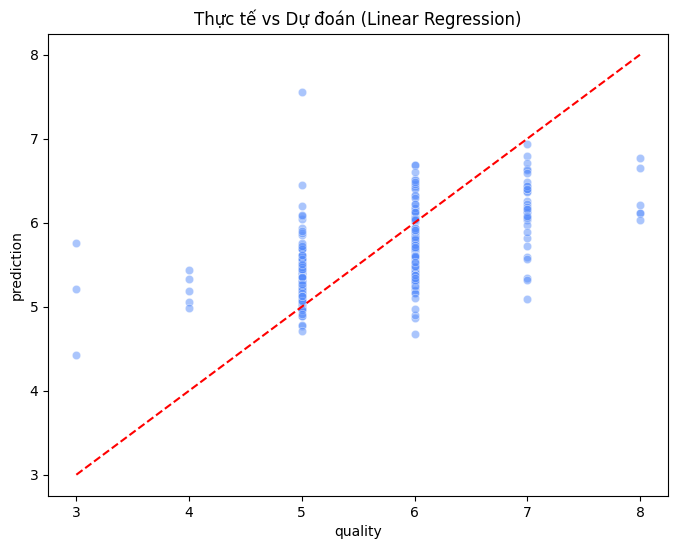

In [59]:
pd_preds_wine = predictions_wine.select("quality", "prediction").toPandas()
plt.figure(figsize=(8, 6))
sns.scatterplot(x='quality', y='prediction', data=pd_preds_wine, alpha=0.5)
plt.plot([3, 8], [3, 8], color='red', linestyle='--')
plt.title("Thực tế vs Dự đoán (Linear Regression)")
plt.show()

# 3.2. Bài 2: Phân loại nhị phân với LinearSVC (Support Vector Classifier)

In [60]:
df_cancer = spark.read.csv(HDFS_PATH + "breast-cancer.csv", header=True, inferSchema=True)

In [61]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

df_cancer = df_cancer.drop("id")
indexer = StringIndexer(inputCol="diagnosis", outputCol="label")
df_cancer = indexer.fit(df_cancer).transform(df_cancer)

feature_cols_cancer = [c for c in df_cancer.columns if c not in ['diagnosis', 'label']]
assembler_cancer = VectorAssembler(inputCols=feature_cols_cancer, outputCol="features", handleInvalid="skip")
df_cancer = assembler_cancer.transform(df_cancer)

In [62]:
from pyspark.ml.classification import LinearSVC

train_cancer, test_cancer = df_cancer.randomSplit([0.8, 0.2], seed=42)
svc = LinearSVC(featuresCol="features", labelCol="label", maxIter=50)
svc_model = svc.fit(train_cancer)

In [63]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix

predictions_cancer = svc_model.transform(test_cancer)

# Tính toán các tiêu chí
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

print("--- ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI KHỐI U ---")
print(f"Accuracy  : {eval_acc.evaluate(predictions_cancer):.4f}")
print(f"F1-Score  : {eval_f1.evaluate(predictions_cancer):.4f}")
print(f"Precision : {eval_prec.evaluate(predictions_cancer):.4f}")
print(f"Recall    : {eval_rec.evaluate(predictions_cancer):.4f}")
print("-----------------------------------------")

--- ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI KHỐI U ---
Accuracy  : 0.9651
F1-Score  : 0.9650
Precision : 0.9652
Recall    : 0.9651
-----------------------------------------


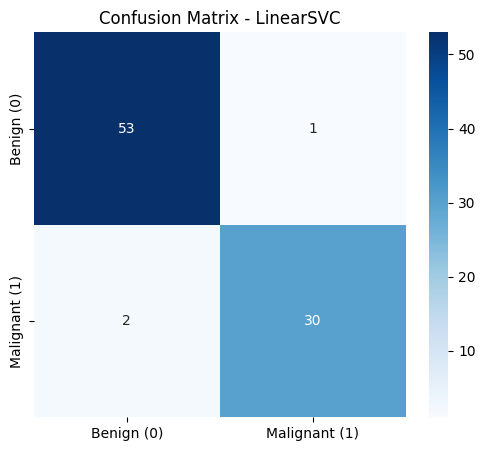

In [64]:
y_true_cancer = predictions_cancer.select("label").toPandas()
y_pred_cancer = predictions_cancer.select("prediction").toPandas()
cm_cancer = confusion_matrix(y_true_cancer, y_pred_cancer)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cancer, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)',
'Malignant (1)'])
plt.title("Confusion Matrix - LinearSVC")
plt.show()

# 3.3. Bài 3: Gom cụm với Spectral Clustering

In [65]:
df_iris = spark.read.csv(HDFS_PATH + "Iris.csv", header=True, inferSchema=True)

In [66]:
features_only_iris = df_iris.drop("species")
pdf_iris = features_only_iris.toPandas()

In [67]:
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler as SklearnStandardScaler

scaler_sk = SklearnStandardScaler()
X_scaled_iris = scaler_sk.fit_transform(pdf_iris)

In [68]:
spectral = SpectralClustering(n_clusters=3, affinity='rbf', random_state=42)
cluster_labels_iris = spectral.fit_predict(X_scaled_iris)

In [69]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Đánh giá mô hình gom cụm
sil_score_iris = silhouette_score(X_scaled_iris, cluster_labels_iris)
dbi_score_iris = davies_bouldin_score(X_scaled_iris, cluster_labels_iris)

print("--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING (IRIS) ---")
print(f"Silhouette Score : {sil_score_iris:.4f} (Càng gần 1 càng tốt)")
print(f"Davies-Bouldin   : {dbi_score_iris:.4f} (Càng nhỏ càng tốt)")
print("---------------------------------------------------")

--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING (IRIS) ---
Silhouette Score : 0.4561 (Càng gần 1 càng tốt)
Davies-Bouldin   : 0.8954 (Càng nhỏ càng tốt)
---------------------------------------------------


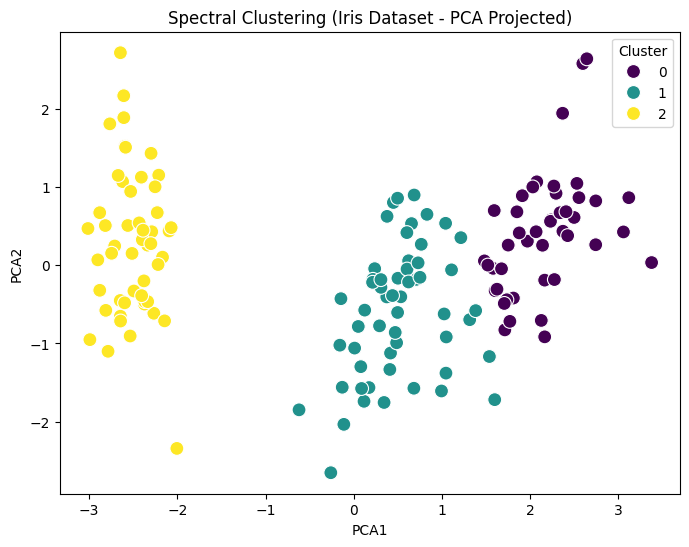

In [70]:
from sklearn.decomposition import PCA

pca_iris = PCA(n_components=2)
X_pca_iris = pca_iris.fit_transform(X_scaled_iris)

pdf_pca_iris = pd.DataFrame(X_pca_iris, columns=['PCA1', 'PCA2'])
pdf_pca_iris['Cluster'] = cluster_labels_iris

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pdf_pca_iris, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100)
plt.title("Spectral Clustering (Iris Dataset - PCA Projected)")
plt.show()

# 4.1. Bài tập 1: Dự đoán mức tiêu thụ nhiên liệu (Hồi quy)
* Dataset: UCI Auto MPG  - link.
* Yêu cầu:
* Gợi ý xử lý lỗi:
Dựa vào các kiến thức và các bước đã được hướng dẫn ở Phần 1, sinh viên tự thực hiện các bài toán sau:

o Xây dựng thuật toán hồi quy để dự đoán cột mpg (Miles per gallon - số dặm đi được trên một gallon nhiên liệu).

o Thử nghiệm trên một số thuật toán hồi quy.

o Trong dataset này, cột horsepower chứa một số giá trị bị thiếu được đánh dấu bằng ký tự ?. Nếu đưa trực tiếp vào mô hình sẽ gây lỗi.

o Sinh viên cần sử dụng các hàm của PySpark DataFrame để lọc bỏ (dropna) hoặc thay thế (impute) các giá trị ? này thành số hợp lệ trước khi đưa vào VectorAssembler.

**Bước 1: Xuất dữ liệu auto-mpg từ hệ thống HDFS**

In [19]:
df_mbg = spark.read.csv(HDFS_PATH + "auto-mpg.csv", header=True, inferSchema=True, sep=",")
df_mbg.show(5)

+----+---------+------------+----------+------+------------+----------+------+--------------------+
| mpg|cylinders|displacement|horsepower|weight|acceleration|model year|origin|            car name|
+----+---------+------------+----------+------+------------+----------+------+--------------------+
|18.0|        8|       307.0|       130|  3504|        12.0|        70|     1|chevrolet chevell...|
|15.0|        8|       350.0|       165|  3693|        11.5|        70|     1|   buick skylark 320|
|18.0|        8|       318.0|       150|  3436|        11.0|        70|     1|  plymouth satellite|
|16.0|        8|       304.0|       150|  3433|        12.0|        70|     1|       amc rebel sst|
|17.0|        8|       302.0|       140|  3449|        10.5|        70|     1|         ford torino|
+----+---------+------------+----------+------+------------+----------+------+--------------------+
only showing top 5 rows


In [20]:
df_mbg.printSchema()

root
 |-- mpg: double (nullable = true)
 |-- cylinders: integer (nullable = true)
 |-- displacement: double (nullable = true)
 |-- horsepower: string (nullable = true)
 |-- weight: integer (nullable = true)
 |-- acceleration: double (nullable = true)
 |-- model year: integer (nullable = true)
 |-- origin: integer (nullable = true)
 |-- car name: string (nullable = true)



**Bước 2: Xử lý giá trị ? trong horsepower**

In [21]:
from pyspark.sql.functions import when, col

df_mbg.filter(col("horsepower") == "?").count()

6

In [22]:
df_mbg = df_mbg.withColumn(
    "horsepower",
    when(col("horsepower") == "?", None)
    .otherwise(col("horsepower"))
)

In [23]:
from pyspark.sql.functions import avg

print(f"Số lượng record chứa horsepower là giá trị null trước impute: {df_mbg.filter(col('horsepower').isNull()).count()}")

mean_hp = df_mbg.select(avg("horsepower")).collect()[0][0]
df_mbg = df_mbg.na.fill({
    "horsepower": int(mean_hp)
})

print(f"Số lượng record chứa horsepower là giá trị null sau impute: {df_mbg.filter(col('horsepower').isNull()).count()}")

Số lượng record chứa horsepower là giá trị null trước impute: 6
Số lượng record chứa horsepower là giá trị null sau impute: 0


In [24]:
# Chuyển đổi kiểu dữ liệu cho cột "horsepower"
df_mbg = df_mbg.withColumn(
    "horsepower",
    col("horsepower").cast("integer")
)

# Drop cột car name
print(f"Phần trăm giá trị khác biệt trong \"car name\" trong tổng số records: "
      f"{round(df_mbg.select("car name").distinct().count()/df_mbg.count(), 2)*100}%")
df_mbg = df_mbg.drop('car name')

Phần trăm giá trị khác biệt trong "car name" trong tổng số records: 77.0%


**Bước 3: Gộp vector và Chuẩn hóa**

In [25]:
# 2. Tiền xử lý (Gộp vector và Chuẩn hóa)
from pyspark.ml.feature import VectorAssembler, StandardScaler

feature_columns = [c for c in df_mbg.columns if c != 'mpg']

assembler = VectorAssembler(inputCols=feature_columns, outputCol="raw_features")
df_mbg = assembler.transform(df_mbg)

In [26]:
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_mbg)
df_mbg_scaled = scaler_model.transform(df_mbg)

**Bước 4: Huấn luyện các mô hình**

# Linear Regression

In [27]:
from pyspark.ml.regression import LinearRegression

train_data_mbg, test_data_mbg = df_mbg_scaled.randomSplit([0.8, 0.2], seed=42)
lr = LinearRegression(featuresCol='features', labelCol='mpg')
lr_model = lr.fit(train_data_mbg)

# Isotonic Regression

In [28]:
from pyspark.ml.regression import IsotonicRegression

ir = IsotonicRegression(featuresCol='features', labelCol='mpg')
ir_model = ir.fit(train_data_mbg)

# Random Forest Regressor

In [29]:
from pyspark.ml.regression import RandomForestRegressor

rfr = RandomForestRegressor(featuresCol='features', labelCol='mpg')
rfr_model = rfr.fit(train_data_mbg)

**Bước 5: Đánh giá các mô hình**

In [30]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_mpg = RegressionEvaluator(labelCol="mpg", predictionCol="prediction", metricName="rmse")

#LR
predictions_lr = lr_model.transform(test_data_mbg)
print(f"RMSE (Linear Regression): {evaluator_mpg.evaluate(predictions_lr):.4f}")

#IR
predictions_ir = ir_model.transform(test_data_mbg)
print(f"RMSE (Isotonic Regression): {evaluator_mpg.evaluate(predictions_ir):.4f}")

#RFR
predictions_rfr = rfr_model.transform(test_data_mbg)
print(f"RMSE (Random Forest Regression): {evaluator_mpg.evaluate(predictions_rfr):.4f}")

RMSE (Linear Regression): 3.3053
RMSE (Isotonic Regression): 7.9270
RMSE (Random Forest Regression): 3.0155


**Bước 6: Trực quan hóa kết quả dự báo**

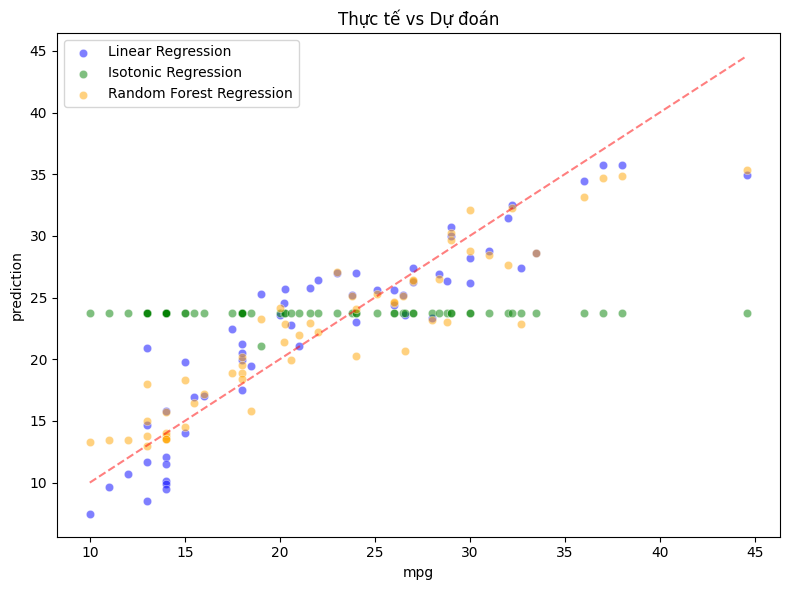

In [31]:
pd_preds_lr = (predictions_lr.select("mpg", "prediction").toPandas())
pd_preds_ir = (predictions_ir.select("mpg", "prediction").toPandas())
pd_preds_rfr = (predictions_rfr.select("mpg", "prediction").toPandas())

plt.figure(figsize=(8, 6))
sns.scatterplot(x='mpg', y='prediction', data=pd_preds_lr, alpha=0.5, color='blue',label = 'Linear Regression')
sns.scatterplot(x='mpg', y='prediction', data=pd_preds_ir, alpha=0.5, color='green',label='Isotonic Regression')
sns.scatterplot(x='mpg', y='prediction', data=pd_preds_rfr, alpha=0.5, color='orange', label='Random Forest Regression')

min_val = min(pd_preds_lr['mpg'])
max_val = max(pd_preds_lr['mpg'])

plt.plot([min_val, max_val], [min_val, max_val], alpha = 0.5, color='red', linestyle='--')
plt.title("Thực tế vs Dự đoán")
plt.tight_layout()
plt.show()

# Bài tập 2: Dự đoán phân khúc thu nhập (Phân loại)
* Yêu cầu:

o Xây dựng mô hình phân lớp (thuật toán tùy chọn) để phân loại xem thu nhập của một cá nhân có lớn hơn 50K/năm hay không (cột nhãn income).

o Thử nghiệm một số thuật toán.
* Gợi ý tiền xử lý:

o Khác với Bài 2 ở Phần 1 (tất cả các đặc trưng đều là số), dataset Adult chứa rất nhiều biến phân loại (Categorical variables) như: workclass, education, marital-status.

o Mô hình không thể học trực tiếp từ chữ. Sinh viên BẮT BUỘC phải sử dụng kết hợp StringIndexer (để chuyển chữ thành số index) và OneHotEncoder (để mã hóa vector) cho tất cả các cột phân loại này. Khuyến khích đưa tất cả các bước này vào một Pipeline của Spark ML.

**Bước 1: Xuất dữ liệu hệ thống HDFS**

In [3]:
df_income = spark.read.csv(HDFS_PATH + "adult.csv", header=True, inferSchema=True, sep=",")
df_income.show(5)

+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|   education|education.num|marital.status|       occupation| relationship| race|   sex|capital.gain|capital.loss|hours.per.week|native.country|income|
+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
| 90|        ?| 77053|     HS-grad|            9|       Widowed|                ?|Not-in-family|White|Female|           0|        4356|            40| United-States| <=50K|
| 82|  Private|132870|     HS-grad|            9|       Widowed|  Exec-managerial|Not-in-family|White|Female|           0|        4356|            18| United-States| <=50K|
| 66|        ?|186061|Some-college|           10|       Widowed|                ?|    Unmarried|Black|Female|           0|        4356|

In [4]:
df_income.printSchema()

root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education.num: integer (nullable = true)
 |-- marital.status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital.gain: integer (nullable = true)
 |-- capital.loss: integer (nullable = true)
 |-- hours.per.week: integer (nullable = true)
 |-- native.country: string (nullable = true)
 |-- income: string (nullable = true)



**Bước 2: Thay đổi tên cột và xử lý các giá trị ? trong categorical features**

In [5]:
for c in df_income.columns:
    df_income = df_income.withColumnRenamed(c, c.replace(".","_"))

In [6]:
from pyspark.sql.functions import col, when

cat_cols = [
    c for c, t in df_income.dtypes
    if t == "string"
]

for c in cat_cols:
    print(f"Column {c}: {df_income.filter(col(c)=='?').count()}")

Column workclass: 1836
Column education: 0
Column marital_status: 0
Column occupation: 1843
Column relationship: 0
Column race: 0
Column sex: 0
Column native_country: 583
Column income: 0


In [7]:
for c in cat_cols:
    df_income = df_income.withColumn(c, when(col(c)=='?',None).otherwise(col(c)))

In [8]:
df_income.show(5)

+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|   education|education_num|marital_status|       occupation| relationship| race|   sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
| 90|     NULL| 77053|     HS-grad|            9|       Widowed|             NULL|Not-in-family|White|Female|           0|        4356|            40| United-States| <=50K|
| 82|  Private|132870|     HS-grad|            9|       Widowed|  Exec-managerial|Not-in-family|White|Female|           0|        4356|            18| United-States| <=50K|
| 66|     NULL|186061|Some-college|           10|       Widowed|             NULL|    Unmarried|Black|Female|           0|        4356|

**Bước 3: Build Pipeline và xây dựng mô hình**

In [17]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, LinearSVC, RandomForestClassifier

#Chia thành các thuộc tính categorical và numeric
cat_cols = [c for c, t in df_income.dtypes if t == 'string' and c!= 'income']
num_cols = [c for c in df_income.columns if c not in cat_cols and c!= 'income']

# Chuyển từ string sang dạng sô cho các thuộc tính categorical và target
tar_indexer = StringIndexer(inputCol="income", outputCol="label")

cat_indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_index",
        handleInvalid="keep"
    )
    for c in cat_cols
]
# Mã hóa các thuộc tính categorical
encoder = OneHotEncoder(
    inputCols=[
        c + "_index"
        for c in cat_cols
    ],
    outputCols=[
        c + "_vec"
        for c in cat_cols
    ]
)

# Ghộp lại thành một vector
assembler = VectorAssembler(
    inputCols=
        num_cols +
        [c + "_vec" for c in cat_cols],
    outputCol="features"
)

# Thiết lập các mô hình
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

svc = LinearSVC(
    featuresCol="features",
    labelCol="label")

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label")


# Xây dựng Pipeline
pipeline = Pipeline(
    stages=[tar_indexer] + cat_indexers + [encoder, assembler]
)

**Bước 4: Phân chia và biến đổi các tập dữ liệu**

In [15]:
# Phân chia tập dữ liệu
train_income, test_income = df_income.randomSplit([0.8, 0.2], seed=42)
data_processed = pipeline.fit(train_income)
train_processed = data_processed.transform(train_income)
test_processed = data_processed.transform(test_income)

**Bước 5: Huấn luyện mô hình**

In [18]:
# Huấn luyện mô hinh
## Logistic Regression
lr_model = lr.fit(train_processed)
predictions_lr = lr_model.transform(test_processed)

## SVC
svc_model = svc.fit(train_processed)
predictions_svc = svc_model.transform(test_processed)

## Random Forest
rf_model = rf.fit(train_processed)
predictions_rf = rf_model.transform(test_processed)

**Bước 6: Đánh giá các mô hình**

In [20]:
# Đánh giá Accuracy các mô hình
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

print("--- ĐÁNH GIÁ ACCURACY GIỮA CÁC MÔ HÌNH ---")
print(f"Accuracy - Logistic Regression: {eval_acc.evaluate(predictions_lr):.4f}")
print(f"Accuracy - SVC: {eval_acc.evaluate(predictions_svc):.4f}")
print(f"Accuracy - Random Forest: {eval_acc.evaluate(predictions_rf):.4f}")
print("-----------------------------------------")

--- ĐÁNH GIÁ ACCURACY GIỮA CÁC MÔ HÌNH ---
Accuracy - Logistic Regression: 0.8509
Accuracy - SVC: 0.8515
Accuracy - Random Forest: 0.8293
-----------------------------------------


In [21]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Tính toán các tiêu chí
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

print("--- ĐÁNH GIÁ MÔ HÌNH SVC PHÂN LOẠI INCOME ---")
print(f"Accuracy  : {eval_acc.evaluate(predictions_svc):.4f}")
print(f"F1-Score  : {eval_f1.evaluate(predictions_svc):.4f}")
print(f"Precision : {eval_prec.evaluate(predictions_svc):.4f}")
print(f"Recall    : {eval_rec.evaluate(predictions_svc):.4f}")
print("-----------------------------------------")

--- ĐÁNH GIÁ MÔ HÌNH SVC PHÂN LOẠI INCOME ---
Accuracy  : 0.8515
F1-Score  : 0.8450
Precision : 0.8448
Recall    : 0.8515
-----------------------------------------


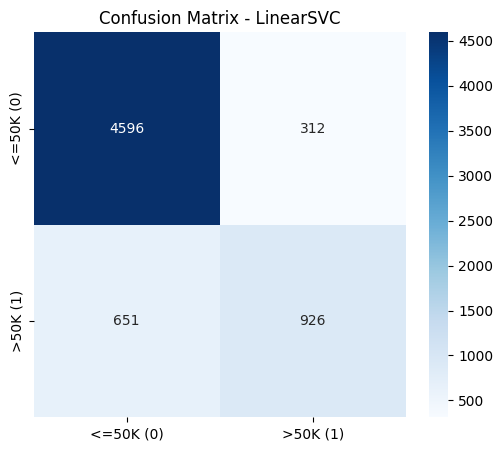

In [24]:
from sklearn.metrics import confusion_matrix

y_true = predictions_svc.select("label").toPandas()
y_pred = predictions_svc.select("prediction").toPandas()
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['<=50K (0)', '>50K (1)'], yticklabels=['<=50K (0)', '>50K (1)'])
plt.title("Confusion Matrix - LinearSVC")
plt.show()

In [23]:
indexer_model = tar_indexer.fit(train_income)
print(indexer_model.labels)

['<=50K', '>50K']


# Bài tập 3: Phân khúc khách hàng bán buôn (Gom cụm)
* Yêu cầu: Sử dụng thuật toán phân cụm (tự chọn) để phân chia các khách hàng (dòng) thành các nhóm
khách hàng có hành vi mua sắm tương đồng dựa trên mức chi tiêu cho các danh mục (Grocery, Milk,
Fresh...).
* Gợi ý thực hiện:

o Đánh giá mô hình.

o Đọc dữ liệu từ HDFS, loại bỏ các cột không phải chi tiêu (như Channel, Region).

o Thu thập (collect) về Pandas DataFrame nếu thuật toán phân cụm không có trong Spark.

o Do mức chi tiêu giữa các danh mục lệch nhau rất lớn (ví dụ: Fresh có thể lên tới chục nghìn, Delicassen chỉ vài trăm), sinh viên bắt buộc phải chuẩn hóa dữ liệu bằng StandardScaler trước khi đưa vào mô hình.

o Thử nghiệm gom thành 3 hoặc 4 cụm (n_clusters).

o (Tùy chọn nâng cao) Vẽ đồ thị PCA 2 chiều để trực quan hóa sự phân bổ của các cụm khách
hàng.

o (Tùy chọn nâng cao) Chạy nhiều thuật toán rồi so sánh.

**Bước 1: Xuất dữ liệu hệ thống HDFS**

In [29]:
df_cus = spark.read.csv(HDFS_PATH + 'wholesale_customers_data.csv', header = True, inferSchema = True, sep = ',')
df_cus.show(5)

+-------+------+-----+----+-------+------+----------------+----------+
|Channel|Region|Fresh|Milk|Grocery|Frozen|Detergents_Paper|Delicassen|
+-------+------+-----+----+-------+------+----------------+----------+
|      2|     3|12669|9656|   7561|   214|            2674|      1338|
|      2|     3| 7057|9810|   9568|  1762|            3293|      1776|
|      2|     3| 6353|8808|   7684|  2405|            3516|      7844|
|      1|     3|13265|1196|   4221|  6404|             507|      1788|
|      2|     3|22615|5410|   7198|  3915|            1777|      5185|
+-------+------+-----+----+-------+------+----------------+----------+
only showing top 5 rows


**Bước 2: Drop các cột không liên quan đến yêu cầu của đề bài**

In [30]:
df_cus = df_cus.drop('Channel', 'Region')
df_cus = df_cus.toPandas()

**Bước 3: Chuẩn hóa numeric features**

In [31]:
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler as SklearnStandardScaler

scaler = SklearnStandardScaler()
X_scaled_cus = scaler.fit_transform(df_cus)

**Bước 4: Tiến hành phân cụm (thành cụm 3 và cụm 4) và đánh giá chất lượng phân cụm**

In [35]:
spectral3 = SpectralClustering(n_clusters=3, affinity='rbf', random_state=42)
cluster_labels3 = spectral3.fit_predict(X_scaled_cus)

from sklearn.metrics import silhouette_score, davies_bouldin_score

# Đánh giá mô hình gom cụm
sil_score3 = silhouette_score(X_scaled_cus, cluster_labels3)
dbi_score3 = davies_bouldin_score(X_scaled_cus, cluster_labels3)

print("--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING với n = 3 ---")
print(f"Silhouette Score : {sil_score3:.4f} (Càng gần 1 càng tốt)")
print(f"Davies-Bouldin   : {dbi_score3:.4f} (Càng nhỏ càng tốt)")
print("---------------------------------------------------")

--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING với n = 3 ---
Silhouette Score : 0.8638 (Càng gần 1 càng tốt)
Davies-Bouldin   : 0.0927 (Càng nhỏ càng tốt)
---------------------------------------------------


C:\Users\thanh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [37]:
spectral4 = SpectralClustering(n_clusters=4, affinity='rbf', random_state=42)
cluster_labels4 = spectral4.fit_predict(X_scaled_cus)

# Đánh giá mô hình gom cụm
sil_score4 = silhouette_score(X_scaled_cus, cluster_labels4)
dbi_score4 = davies_bouldin_score(X_scaled_cus, cluster_labels4)

print("--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING với n = 4 ---")
print(f"Silhouette Score : {sil_score4:.4f} (Càng gần 1 càng tốt)")
print(f"Davies-Bouldin   : {dbi_score4:.4f} (Càng nhỏ càng tốt)")
print("---------------------------------------------------")

--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING với n = 4 ---
Silhouette Score : 0.8638 (Càng gần 1 càng tốt)
Davies-Bouldin   : 0.0927 (Càng nhỏ càng tốt)
---------------------------------------------------


C:\Users\thanh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


**Bước 5: Trực quan hóa dữ liệu đã được phân cụm bằng giảm chiều PCA**

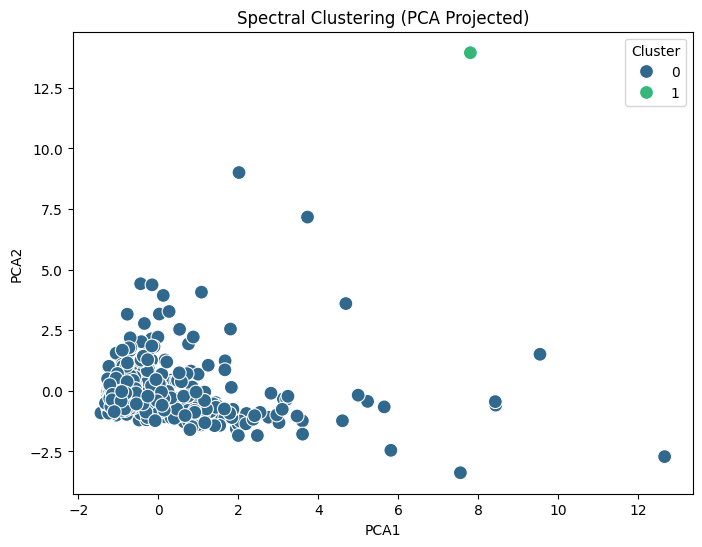

In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_cus = pca.fit_transform(X_scaled_cus)

df_pca_cus = pd.DataFrame(X_pca_cus, columns=['PCA1', 'PCA2'])
df_pca_cus['Cluster'] = cluster_labels3

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca_cus, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100)
plt.title("Spectral Clustering (PCA Projected)")
plt.show()

**Xem thử cụm 1**

In [50]:
df_cus['Cluster'] = cluster_labels3

In [53]:
df_cus[df_cus["Cluster"]==1]

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
183,36847,43950,20170,36534,239,47943,1
